# Model Comparison Notebook

This notebook loads the saved result files from the three models and compares them in a consistent way.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [ ]:
linear_file = "linear_regression_statistics.npy"
transformer_file = "transformer_statistics.npy"
exp_file = "exponential_smoothing_statistics.npy"

linear_results = np.load(linear_file, allow_pickle=True).item()
transformer_results = np.load(transformer_file, allow_pickle=True).item()
exp_results = np.load(exp_file, allow_pickle=True).item()

print("All models loaded successfully!")

All models loaded successfully!


In [ ]:
print("Linear keys:\n", sorted(linear_results.keys()), "\n")
print("Transformer keys:\n", sorted(transformer_results.keys()), "\n")
print("Exponential smoothing keys:\n", sorted(exp_results.keys()))

Linear keys:
 ['Y_pred_all', 'Y_test_all', 'horizon', 'mean_roi_mse', 'mean_run_mse', 'model_name', 'num_rois', 'overall_mse', 'roi_mse', 'run_level_mse', 'scaled_mse', 'std_roi_mse', 'std_run_mse', 'test_runs', 'test_sample_run_ids', 'window_size'] 

Transformer keys:
 ['Y_pred_all', 'Y_test_all', 'horizon', 'mean_roi_mse', 'mean_run_mse', 'model_name', 'num_rois', 'overall_mse', 'roi_mse', 'run_level_mse', 'scaled_mse', 'std_roi_mse', 'std_run_mse', 'test_runs', 'test_sample_run_ids', 'window_size'] 

Exponential smoothing keys:
 ['Y_pred_all', 'Y_test_all', 'horizon', 'mean_roi_mse', 'mean_run_mse', 'model_name', 'num_rois', 'overall_mse', 'roi_mse', 'run_level_mse', 'scaled_mse', 'std_roi_mse', 'std_run_mse', 'test_files', 'test_runs', 'test_sample_run_ids', 'window_size']


In [ ]:
shared_var = np.var(linear_results["Y_test_all"])
linear_pve = 1 - (linear_results["overall_mse"] / shared_var)
transformer_pve = 1 - (transformer_results["overall_mse"] / shared_var)
exp_pve = 1 - (exp_results["overall_mse"] / shared_var)

In [ ]:
import numpy as np

def compute_overall_correlation(y_true, y_pred):

    '''
    - correlation = 1   -> perfect positive agreement
    - correlation = 0   -> no linear relationship
    - correlation = -1  -> perfect inverse relationship
    '''

    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    # If either array has zero variance, correlation is undefined.
    # That would mean one signal is constant, so there is no meaningful
    # way to measure whether they move together.
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan

    return np.corrcoef(y_true, y_pred)[0, 1]


def compute_roi_correlations(y_true, y_pred):
    """
    Compute Pearson correlation separately for each ROI.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    num_rois = y_true.shape[1]
    roi_corrs = []

    for roi_idx in range(num_rois):
        true_roi = y_true[:, roi_idx]
        pred_roi = y_pred[:, roi_idx]
        if np.std(true_roi) == 0 or np.std(pred_roi) == 0:
            roi_corrs.append(np.nan)
        else:
            roi_corrs.append(np.corrcoef(true_roi, pred_roi)[0, 1])

    return np.array(roi_corrs)

In [ ]:
print("True var:", np.var(linear_results["Y_test_all"]))

True var: 0.9045116212002042


In [ ]:
# Overall correlation for each model
# This gives one number per model summarizing how strongly the predictions
# align with the true signal across all samples and all ROIs.

linear_corr = compute_overall_correlation(
    linear_results["Y_test_all"],
    linear_results["Y_pred_all"]
)

transformer_corr = compute_overall_correlation(
    transformer_results["Y_test_all"],
    transformer_results["Y_pred_all"]
)

exp_corr = compute_overall_correlation(
    exp_results["Y_test_all"],
    exp_results["Y_pred_all"]
)

print("Linear Regression overall correlation:", linear_corr)
print("Transformer overall correlation:", transformer_corr)
print("Exponential Smoothing overall correlation:", exp_corr)

Linear Regression overall correlation: 0.6849538696316805
Transformer overall correlation: 0.6885102440911486
Exponential Smoothing overall correlation: 0.7322527248314217


In [ ]:
# Correlation for each ROI separately
# This helps us see whether model performance is consistent across brain regions
# or whether some ROIs are much easier / harder to predict.

linear_roi_corrs = compute_roi_correlations(
    linear_results["Y_test_all"],
    linear_results["Y_pred_all"]
)

transformer_roi_corrs = compute_roi_correlations(
    transformer_results["Y_test_all"],
    transformer_results["Y_pred_all"]
)

exp_roi_corrs = compute_roi_correlations(
    exp_results["Y_test_all"],
    exp_results["Y_pred_all"]
)

print("Linear ROI correlations:\n", linear_roi_corrs)
print("\nTransformer ROI correlations:\n", transformer_roi_corrs)
print("\nExponential Smoothing ROI correlations:\n", exp_roi_corrs)

Linear ROI correlations:
 [0.55843816 0.62284664 0.6232869  0.79873635 0.55841853 0.73860105
 0.56380491 0.55134605 0.53322709 0.54384004 0.57493018 0.86010792
 0.81864499 0.89328439 0.72888159 0.84573778 0.60426275 0.69645144]

Transformer ROI correlations:
 [0.56059559 0.6244406  0.62470484 0.80271206 0.55912423 0.73949401
 0.57038425 0.55517259 0.54836675 0.54652853 0.57829148 0.86245332
 0.8216625  0.89378758 0.73961905 0.84628028 0.62832721 0.70242307]

Exponential Smoothing ROI correlations:
 [0.58609003 0.68070006 0.75879716 0.8565107  0.6104512  0.81077885
 0.63180191 0.61141834 0.49247156 0.51964729 0.62813497 0.87015797
 0.81082368 0.88316633 0.83860241 0.82420146 0.70059179 0.71361542]


In [ ]:
# Summarize the ROI-level correlations with mean and standard deviation.
# Mean ROI correlation tells us the average alignment across brain regions.
# Std ROI correlation tells us how uneven performance is across ROIs.

linear_mean_corr = np.nanmean(linear_roi_corrs)
linear_std_corr = np.nanstd(linear_roi_corrs)

transformer_mean_corr = np.nanmean(transformer_roi_corrs)
transformer_std_corr = np.nanstd(transformer_roi_corrs)

exp_mean_corr = np.nanmean(exp_roi_corrs)
exp_std_corr = np.nanstd(exp_roi_corrs)

print("Linear Regression mean ROI correlation:", linear_mean_corr)

print("\nTransformer mean ROI correlation:", transformer_mean_corr)

print("\nExponential Smoothing mean ROI correlation:", exp_mean_corr)

Linear Regression mean ROI correlation: 0.6730470427926979

Transformer mean ROI correlation: 0.6780204409060663

Exponential Smoothing mean ROI correlation: 0.7126645074784091


Correlation measures how consistently the two signals vary together, but does not penalize differences in magnitude or fine-scale structure. In our case, exponential smoothing produces a smoothed version of the signal that captures low-frequency trends well, leading to consistent directional agreement with the true signal. As a result, the product is often positive, yielding a higher correlation. However, this does not imply better predictive performance, as the model fails to capture high-frequency variations, which are important for minimizing error and maximizing variance explained.

In [ ]:
def compute_overall_covariance(y_true, y_pred):
    """
    Compute overall covariance between true and predicted signals.
    - This depends on scale (unlike correlation)
    """

    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    # np.cov returns a 2x2 matrix:
    # [ var(y_true), cov(y_true, y_pred)
    #   cov(y_pred, y_true), var(y_pred) ]
    cov_matrix = np.cov(y_true, y_pred)

    return cov_matrix[0, 1]

In [ ]:
def compute_roi_covariances(y_true, y_pred):
    """
    Compute covariance for each ROI separately.
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    num_rois = y_true.shape[1]
    roi_covs = []

    for roi_idx in range(num_rois):
        true_roi = y_true[:, roi_idx]
        pred_roi = y_pred[:, roi_idx]

        cov_matrix = np.cov(true_roi, pred_roi)
        roi_covs.append(cov_matrix[0, 1])

    return np.array(roi_covs)

In [ ]:
linear_cov = compute_overall_covariance(
    linear_results["Y_test_all"],
    linear_results["Y_pred_all"]
)

transformer_cov = compute_overall_covariance(
    transformer_results["Y_test_all"],
    transformer_results["Y_pred_all"]
)

exp_cov = compute_overall_covariance(
    exp_results["Y_test_all"],
    exp_results["Y_pred_all"]
)

print("Linear Regression covariance:", linear_cov)
print("Transformer covariance:", transformer_cov)
print("Exponential Smoothing covariance:", exp_cov)

Linear Regression covariance: 0.4253537544289132
Transformer covariance: 0.42809272554462985
Exponential Smoothing covariance: 0.8903328634973632


In [ ]:
linear_roi_covs = compute_roi_covariances(
    linear_results["Y_test_all"],
    linear_results["Y_pred_all"]
)

transformer_roi_covs = compute_roi_covariances(
    transformer_results["Y_test_all"],
    transformer_results["Y_pred_all"]
)

exp_roi_covs = compute_roi_covariances(
    exp_results["Y_test_all"],
    exp_results["Y_pred_all"]
)

print("Linear mean ROI covariance:", np.mean(linear_roi_covs))
print("Transformer mean ROI covariance:", np.mean(transformer_roi_covs))
print("Exp smoothing mean ROI covariance:", np.mean(exp_roi_covs))

Linear mean ROI covariance: 0.4250670633987765
Transformer mean ROI covariance: 0.42781066312585875
Exp smoothing mean ROI covariance: 0.8586991065843637


Although exponential smoothing produced the highest covariance with the ground truth, this does not imply that it is the best predictive model. Covariance depends on the scale of the signals, and the exponential smoothing predictions have substantially larger variance than the linear and transformer predictions. This inflates the covariance value. For this reason, covariance is less reliable for comparing model quality across methods, while normalized metrics such as correlation and PVE provide a more meaningful comparison.

In [ ]:
print("Linear var pred:", np.var(linear_results["Y_pred_all"]))
print("Transformer var pred:", np.var(transformer_results["Y_pred_all"]))
print("Exp var pred:", np.var(exp_results["Y_pred_all"]))

Linear var pred: 0.4263471020985804
Transformer var pred: 0.42740574
Exp var pred: 0.9841977803362582


## 1) Overall MSE and scaled MSE table

**What this is:**  
This creates the main summary table.

**What data we are comparing:**  
These are scalar summary numbers:
- **Overall MSE:** one number per model
- **Scaled MSE:** one number per model

These are not matrices. They are single values summarizing model error over the saved test outputs.

**Why it matters:**  
- **Overall MSE** tells you the average prediction error size.
- **Scaled MSE** tells you that error relative to the natural step-to-step variability of the signal, so it is easier to interpret across methods.

In [ ]:
comparison_df = pd.DataFrame([
    {
        "Model": linear_results["model_name"],
        "Overall MSE": linear_results["overall_mse"],
        "RMSE": np.sqrt(linear_results["overall_mse"]),
        "Scaled MSE": linear_results["scaled_mse"],
        "RMSSE": np.sqrt(linear_results["scaled_mse"]),
        "PVE": linear_pve,

        # Correlation (normalized)
        "Overall Corr": linear_corr,
        "Mean ROI Corr": linear_mean_corr,
        "Std ROI Corr": linear_std_corr,

        # Covariance (unnormalized)
        "Overall Cov": linear_cov,
        "Mean ROI Cov": np.mean(linear_roi_covs),
        "Std ROI Cov": np.std(linear_roi_covs),

        "Mean ROI MSE": linear_results["mean_roi_mse"],
        "Std ROI MSE": linear_results["std_roi_mse"],
        "Mean Run MSE": linear_results["mean_run_mse"],
        "Std Run MSE": linear_results["std_run_mse"],
    },
    {
        "Model": transformer_results["model_name"],
        "Overall MSE": transformer_results["overall_mse"],
        "RMSE": np.sqrt(transformer_results["overall_mse"]),
        "Scaled MSE": transformer_results["scaled_mse"],
        "RMSSE": np.sqrt(transformer_results["scaled_mse"]),
        "PVE": transformer_pve,

        # Correlation
        "Overall Corr": transformer_corr,
        "Mean ROI Corr": transformer_mean_corr,
        "Std ROI Corr": transformer_std_corr,

        # Covariance
        "Overall Cov": transformer_cov,
        "Mean ROI Cov": np.mean(transformer_roi_covs),
        "Std ROI Cov": np.std(transformer_roi_covs),

        "Mean ROI MSE": transformer_results["mean_roi_mse"],
        "Std ROI MSE": transformer_results["std_roi_mse"],
        "Mean Run MSE": transformer_results["mean_run_mse"],
        "Std Run MSE": transformer_results["std_run_mse"],
    },
    {
        "Model": exp_results["model_name"],
        "Overall MSE": exp_results["overall_mse"],
        "RMSE": np.sqrt(exp_results["overall_mse"]),
        "Scaled MSE": exp_results["scaled_mse"],
        "RMSSE": np.sqrt(exp_results["scaled_mse"]),
        "PVE": exp_pve,

        # Correlation
        "Overall Corr": exp_corr,
        "Mean ROI Corr": exp_mean_corr,
        "Std ROI Corr": exp_std_corr,

        # Covariance
        "Overall Cov": exp_cov,
        "Mean ROI Cov": np.mean(exp_roi_covs),
        "Std ROI Cov": np.std(exp_roi_covs),

        "Mean ROI MSE": exp_results["mean_roi_mse"],
        "Std ROI MSE": exp_results["std_roi_mse"],
        "Mean Run MSE": exp_results["mean_run_mse"],
        "Std Run MSE": exp_results["std_run_mse"],
    }
])

comparison_df

,Model,Overall MSE,RMSE,Scaled MSE,RMSSE,PVE,Overall Corr,Mean ROI Corr,Std ROI Corr,Overall Cov,Mean ROI Cov,Std ROI Cov,Mean ROI MSE,Std ROI MSE,Mean Run MSE,Std Run MSE
0,Linear Regression (Ridge),0.480152,0.692930,0.715492,0.845868,0.469159,0.684954,0.673047,0.121768,0.425354,0.425067,0.159206,0.480152,0.156393,0.480152,0.093017
1,Transformer,0.475755,0.689750,0.708940,0.841986,0.474020,0.688510,0.678020,0.120200,0.428093,0.427811,0.159459,0.475755,0.156047,0.475765,0.092400
2,Exponential Smoothing,0.705585,0.839991,1.120684,1.058624,0.219927,0.732253,0.712665,0.120547,0.890333,0.858699,0.308455,0.705585,0.234957,0.705585,1.662536


To better interpret model performance beyond standard error metrics, we compute the Percent Variance Explained (PVE) for each model. PVE measures how much of the variability in the true signal is captured by the model’s predictions. A PVE value close to 1 indicates that the model explains most of the signal’s structure, while a value near 0 indicates that the model captures very little. Negative values would indicate performance worse than simply predicting the mean.

From the results, the transformer achieves the highest PVE (≈ 0.474), followed closely by linear regression (≈ 0.469). This suggests that both models are able to capture a similar portion of the signal variance, with the transformer providing a slight improvement. This is consistent with the expectation that the transformer can model more complex temporal relationships compared to a linear model.

In contrast, exponential smoothing has a significantly lower PVE (≈ 0.220), indicating that it explains much less of the signal variance. This suggests that while exponential smoothing can capture general trends, it fails to model the more complex dynamics present in the data.

Overall, although the differences in RMSE between the linear and transformer models are relatively small, PVE provides a more interpretable measure of how much of the underlying signal is captured. Both models explain roughly 47% of the variance, while exponential smoothing performs substantially worse, reinforcing its role as a simpler baseline.

Mutual information between two random variables X and Y measures how much knowing one reduces uncertainty about the other.

## 2) Plot overall MSE and scaled MSE

**What this is:**  
Two bar plots: one for overall MSE and one for scaled MSE.

**What data we are comparing:**  
Each bar is one scalar value from the summary table above.

**Why it matters:**  
This is the fastest visual way to see which model has lower total error and whether the ranking changes when the error is scaled.

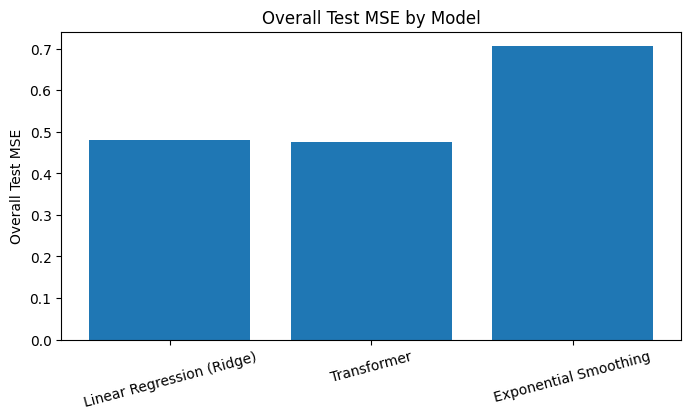

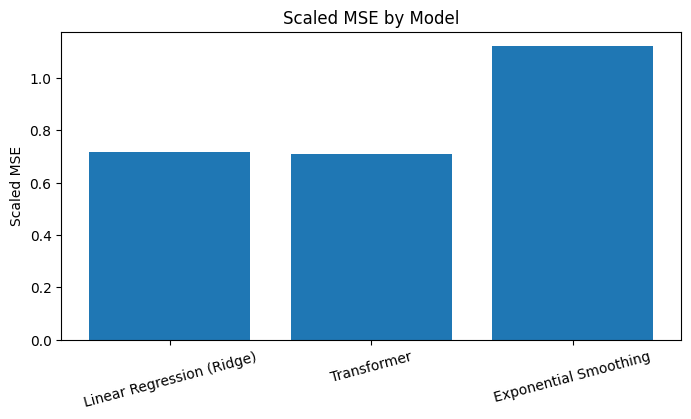

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(comparison_df["Model"], comparison_df["Overall MSE"])
plt.ylabel("Overall Test MSE")
plt.title("Overall Test MSE by Model")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(comparison_df["Model"], comparison_df["Scaled MSE"])
plt.ylabel("Scaled MSE")
plt.title("Scaled MSE by Model")
plt.xticks(rotation=15)
plt.show()

The scaled MSE results mirror the raw MSE trends, confirming that the transformer and linear models perform similarly while exponential smoothing remains significantly worse, independent of scaling effects.

## 3) Per-ROI performance table

**What this is:**  
This builds a table with one row per ROI and one column per model.

**What data we are comparing:**  
This is a **matrix-like table**:
- rows = ROI index
- columns = model
- entries = MSE for that ROI

So each model contributes a 1D vector `roi_mse` of length `num_rois`.

**Why it matters:**  
A single overall MSE can hide a lot. Per-ROI MSE shows whether some brain regions are easier or harder to predict and whether a model is consistently good across ROIs.

In [ ]:
roi_df = pd.DataFrame({
    "ROI": np.arange(len(linear_results["roi_mse"])),
    linear_results["model_name"]: linear_results["roi_mse"],
    transformer_results["model_name"]: transformer_results["roi_mse"],
    exp_results["model_name"]: exp_results["roi_mse"],
})

roi_df

,ROI,Linear Regression (Ridge),Transformer,Exponential Smoothing
0,0,0.632016,0.635525,0.908868
1,1,0.565349,0.564615,0.852203
2,2,0.553967,0.555064,0.646777
3,3,0.320608,0.315391,0.426723
4,4,0.492153,0.491856,0.928147
5,5,0.411849,0.410883,0.548280
6,6,0.625981,0.621768,0.962461
7,7,0.645218,0.643706,0.849161
8,8,0.675207,0.661555,1.098073
9,9,0.663535,0.662307,1.044528


Per-ROI analysis shows substantial variability in predictability across brain regions, with the transformer and linear models performing similarly across most ROIs, while exponential smoothing consistently underperforms.

## 4) Sensitivity/Robustness Analysis

**What this is:**  
This compares error across held-out runs.

**What data we are comparing:**  
Each model contributes a 1D vector `run_level_mse`:
- one value per held-out run

This is another matrix-like table:
- rows = run index
- columns = model
- entries = MSE on that run

**Why it matters:**  
This shows whether a model is stable across different unseen runs. A model with good average performance but very large variation across runs may be less reliable.

In [ ]:
min_num_runs = min(
    len(linear_results["run_level_mse"]),
    len(transformer_results["run_level_mse"]),
    len(exp_results["run_level_mse"]),
)

run_df = pd.DataFrame({
    "Run Index": np.arange(min_num_runs),
    linear_results["model_name"]: linear_results["run_level_mse"][:min_num_runs],
    transformer_results["model_name"]: transformer_results["run_level_mse"][:min_num_runs],
    exp_results["model_name"]: exp_results["run_level_mse"][:min_num_runs],
})

run_df

,Run Index,Linear Regression (Ridge),Transformer,Exponential Smoothing
0,0,0.542048,0.495530,0.537996
1,1,0.540738,0.437543,0.467370
2,2,0.591164,0.437047,0.635773
3,3,0.617177,0.404250,1.356310
4,4,0.512665,0.593741,0.647488
...,...,...,...,...
571,571,0.442419,0.577632,0.652702
572,572,0.440337,0.410807,0.504775
573,573,0.353022,0.346425,0.208699
574,574,0.468948,0.717773,1.405454


Try SNS KDE Plots

Run-level MSE reveals that both the transformer and linear regression models exhibit relatively stable performance across runs, whereas exponential smoothing shows high variability and occasional large errors, indicating poor robustness.

## 5) Drawn output: true vs predicted values

**What this is:**  
This is the most direct output comparison: plotting true signal values and predicted signal values for one ROI.

**What data we are comparing:**  
Each model saved:
- `Y_test_all`
- `Y_pred_all`

These are 2D arrays:
- rows = test samples
- columns = ROI index

For exponential smoothing, the number of samples is smaller because it predicts one future value per ROI per test run, so we trim all models to the shortest available length for plotting.

**Why it matters:**  
MSE gives one summary number, but this plot lets you actually see whether predictions track the shape of the true signal.

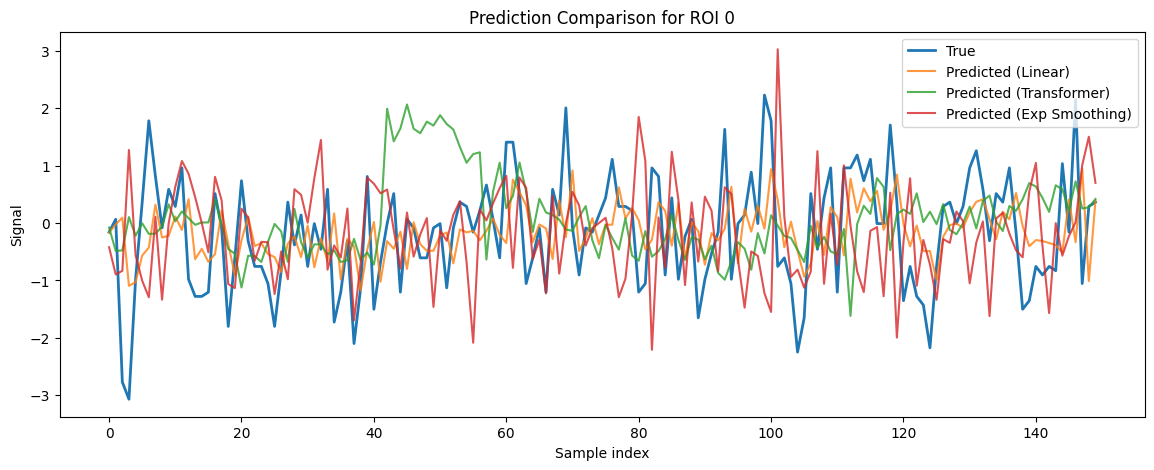

In [ ]:
roi_to_plot = 0

linear_true = linear_results["Y_test_all"][:, roi_to_plot]
linear_pred = linear_results["Y_pred_all"][:, roi_to_plot]

transformer_true = transformer_results["Y_test_all"][:, roi_to_plot]
transformer_pred = transformer_results["Y_pred_all"][:, roi_to_plot]

exp_true = exp_results["Y_test_all"][:, roi_to_plot]
exp_pred = exp_results["Y_pred_all"][:, roi_to_plot]

n = min(len(linear_true), len(transformer_true), len(exp_true), 150)

plt.figure(figsize=(14, 5))
plt.plot(linear_true[:n], label="True", linewidth=2)
plt.plot(linear_pred[:n], label="Predicted (Linear)", alpha=0.8)
plt.plot(transformer_pred[:n], label="Predicted (Transformer)", alpha=0.8)
plt.plot(exp_pred[:n], label="Predicted (Exp Smoothing)", alpha=0.8)
plt.xlabel("Sample index")
plt.ylabel("Signal")
plt.title(f"Prediction Comparison for ROI {roi_to_plot}")
plt.legend()
plt.show()

The prediction comparison shows that the transformer better captures temporal structure than linear regression, while exponential smoothing produces lagged and oversmoothed predictions that fail to track rapid signal changes.

HemoDynamic Response

## 7) Absolute error distribution

**What this is:**  
This compares how large the prediction errors are across all saved test points.

**What data we are comparing:**  
For each model, we compute:
- `abs(Y_test_all - Y_pred_all)`

This creates a 2D error matrix, which is then flattened into one long vector of absolute errors.

**Why it matters:**  
This shows the spread of prediction errors, not just the mean. Two models can have similar MSE but very different error distributions.

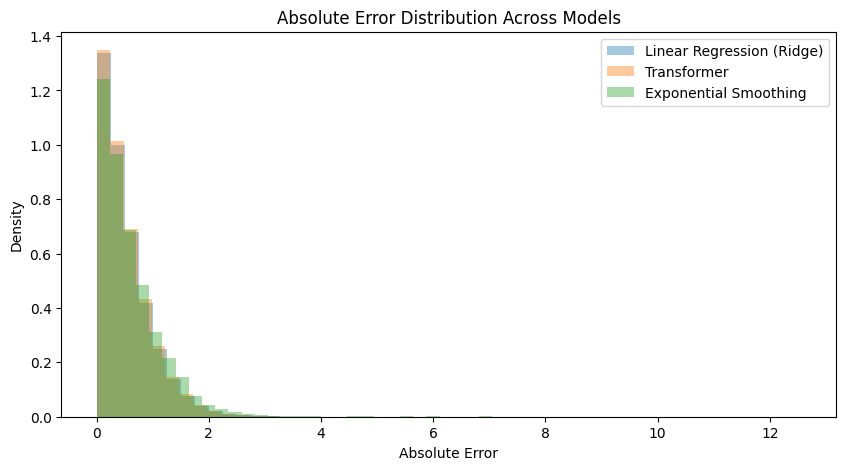

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(linear_abs_error, bins=50, alpha=0.4, density=True, label=linear_results["model_name"])
plt.hist(transformer_abs_error, bins=50, alpha=0.4, density=True, label=transformer_results["model_name"])
plt.hist(exp_abs_error, bins=50, alpha=0.4, density=True, label=exp_results["model_name"])
plt.xlabel("Absolute Error")
plt.ylabel("Density")
plt.title("Absolute Error Distribution Across Models")
plt.legend()
plt.show()

KDE Plot

The absolute error distribution indicates that while all models produce many small errors, exponential smoothing exhibits a heavier tail, reflecting a higher frequency of large prediction errors compared to the transformer and linear models.

## 8) Relative improvement over linear regression

**What this is:**  
This measures how much better or worse the other models are compared to linear regression in terms of overall MSE.

**What data we are comparing:**  
These are scalar values computed from the models' overall MSE values.

**Why it matters:**  
It makes the comparison easier to read than raw MSE alone. A percentage improvement is often easier to explain in slides or discussion.

In [ ]:
linear_mse = linear_results["overall_mse"]

improvement_df = pd.DataFrame([
    {
        "Model": transformer_results["model_name"],
        "% Improvement vs Linear": 100 * (linear_mse - transformer_results["overall_mse"]) / linear_mse
    },
    {
        "Model": exp_results["model_name"],
        "% Improvement vs Linear": 100 * (linear_mse - exp_results["overall_mse"]) / linear_mse
    }
])

improvement_df

,Model,% Improvement vs Linear
0,Transformer,0.915716
1,Exponential Smoothing,-46.950470


## 9) Save comparison tables

**What this is:**  
This saves the main tables from this notebook.

**What data we are saving:**  
- overall summary table
- per-ROI table
- run-level table
- relative improvement table

**Why it matters:**  
This makes it easier to reuse the results in a report, slide deck, or later analysis without re-running the notebook.

In [ ]:
comparison_df.to_csv("/content/model_comparison_table.csv", index=False)
roi_df.to_csv("/content/per_roi_comparison_table.csv", index=False)
run_df.to_csv("/content/run_level_comparison_table.csv", index=False)
improvement_df.to_csv("/content/improvement_vs_linear.csv", index=False)

print("Saved:")
print("- /content/model_comparison_table.csv")
print("- /content/per_roi_comparison_table.csv")
print("- /content/run_level_comparison_table.csv")
print("- /content/improvement_vs_linear.csv")

Saved:
- /content/model_comparison_table.csv
- /content/per_roi_comparison_table.csv
- /content/run_level_comparison_table.csv
- /content/improvement_vs_linear.csv


## 10) Short interpretation summary

**What this is:**  
A short automatic summary of the comparison.

**Why it matters:**  
This gives a quick readable takeaway before writing a final paragraph for Arda or for slides.

In [ ]:
best_mse_model = comparison_df.loc[comparison_df["Overall MSE"].idxmin(), "Model"]
best_scaled_model = comparison_df.loc[comparison_df["Scaled MSE"].idxmin(), "Model"]
lowest_run_var_model = comparison_df.loc[comparison_df["Std Run MSE"].idxmin(), "Model"]
lowest_roi_var_model = comparison_df.loc[comparison_df["Std ROI MSE"].idxmin(), "Model"]

print("Summary:")
print(f"- Best overall MSE: {best_mse_model}")
print(f"- Best scaled MSE: {best_scaled_model}")
print(f"- Most stable across runs: {lowest_run_var_model}")
print(f"- Most consistent across ROIs: {lowest_roi_var_model}")
print()


Summary:
- Best overall MSE: Transformer
- Best scaled MSE: Transformer
- Most stable across runs: Transformer
- Most consistent across ROIs: Transformer

